In [1]:
import numpy as np
import pandas as pd
import scipy
import random
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from math import pi
from scipy.interpolate import NearestNDInterpolator

%matplotlib inline


#floris simulation modules
from floris.tools.wind_rose import WindRose
from floris.tools import FlorisInterface
import floris.tools.visualization as wakeviz
from floris.tools.layout_functions import visualize_layout
from floris.turbine_library import TurbineInterface, TurbineLibrary
from floris.tools.visualization import (
    calculate_horizontal_plane_with_turbines,
    visualize_cut_plane,
)

In [2]:
data = [[77.24, 92.734, 16.708],
    [77.257, 92.754, 16.707],
    [77.274, 92.772, 16.706],
    [77.289, 92.789, 16.705],
    [77.303, 92.806, 16.705],
    [77.316, 92.821, 16.704],
    [77.329, 92.835, 16.703],
    [77.341, 92.849, 16.703],
    [77.352, 92.861, 16.702],
    [77.362, 92.873, 16.701],
    [77.372, 92.885, 16.701],
    [77.381, 92.895, 16.7],
    [77.39, 92.906, 16.7],
    [77.399, 92.915, 16.7],
    [77.407, 92.924, 16.699],
    [77.414, 92.933, 16.699],
    [77.421, 92.941, 16.698],
    [77.428, 92.949, 16.698],
    [77.435, 92.956, 16.698],
    [77.441, 92.963, 16.697],
    [77.447, 92.97, 16.697]]

v_wake = [row[0] for row in data]
v_nowake = [row[1] for row in data]
v_loss = [row[2] for row in data]

data_2 = [[72.424, 86.978, 16.733],
 [72.437, 86.993, 16.732],
 [72.451, 87.007, 16.73],
 [72.464, 87.021, 16.729],
 [72.476, 87.034, 16.727],
 [72.488, 87.047, 16.726],
 [72.499, 87.06, 16.724],
 [72.511, 87.072, 16.723],
 [72.522, 87.084, 16.722],
 [72.532, 87.095, 16.721],
 [72.542, 87.106, 16.72],
 [72.552, 87.117, 16.718],
 [72.562, 87.127, 16.717],
 [72.571, 87.137, 16.716],
 [72.58, 87.147, 16.715],
 [72.589, 87.156, 16.714],
 [72.597, 87.165, 16.713],
 [72.605, 87.174, 16.712],
 [72.613, 87.183, 16.711],
 [72.621, 87.191, 16.711],
 [72.628, 87.199, 16.71]]


n_wake = [row[0] for row in data_2]
n_nowake = [row[1] for row in data_2]
n_loss = [row[2] for row in data_2]


In [3]:
n_x = [i for i in range(90, 111, 1)]
v_x = [i for i in range(45, 66, 1)]

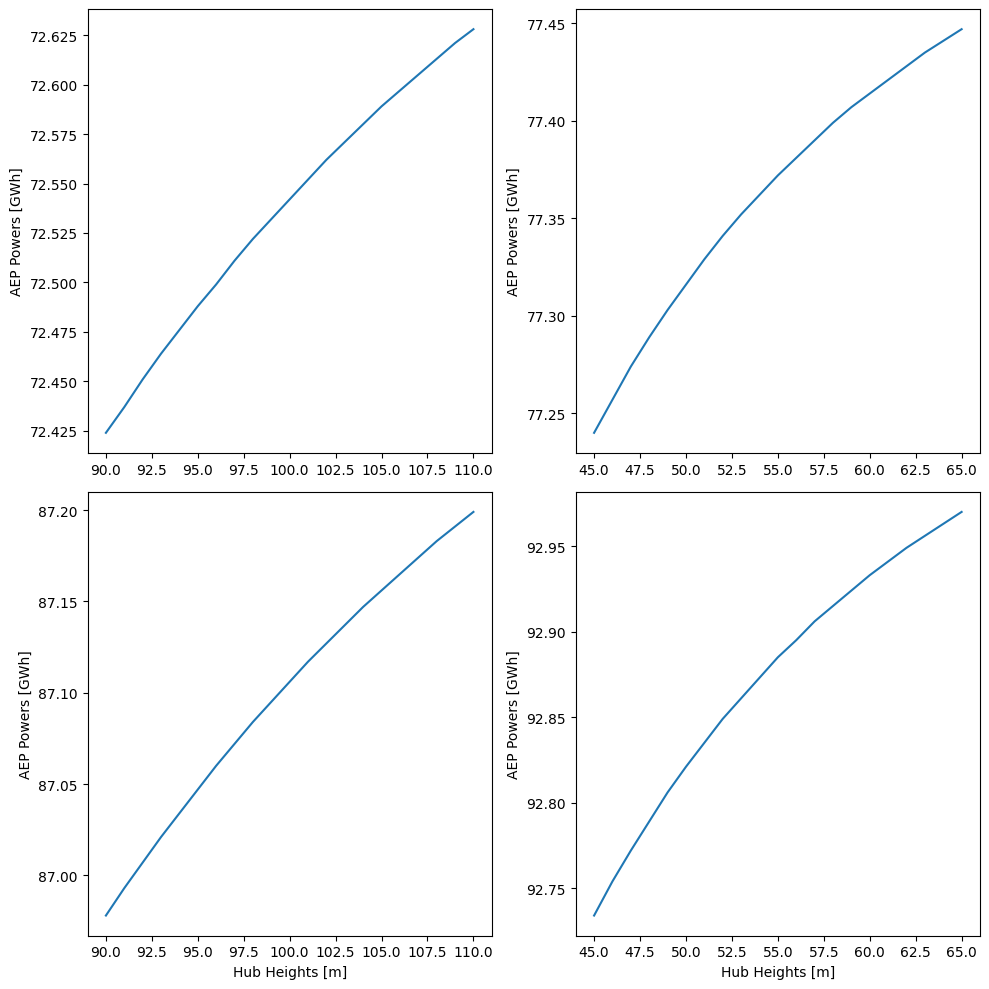

In [4]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Plot for n_wake
axs[0, 0].plot(n_x, n_wake)
# axs[0, 0].set_xlabel('Hub Heights [m]')
axs[0, 0].set_ylabel('AEP Powers [GWh]')
# axs[0, 0].set_title('n_wake')

# Plot for v_wake
axs[0, 1].plot(v_x, v_wake)
# axs[0, 1].set_xlabel('Hub Heights [m]')
axs[0, 1].set_ylabel('AEP Powers [GWh]')
# axs[0, 1].set_title('v_wake')

# Plot for n_nowake
axs[1, 0].plot(n_x, n_nowake)
axs[1, 0].set_xlabel('Hub Heights [m]')
axs[1, 0].set_ylabel('AEP Powers [GWh]')
# axs[1, 0].set_title('n_nowake')

# Plot for v_nowake
axs[1, 1].plot(v_x, v_nowake)
axs[1, 1].set_xlabel('Hub Heights [m]')
axs[1, 1].set_ylabel('AEP Powers [GWh]')
# axs[1, 1].set_title('v_nowake')

plt.tight_layout()  # Adjust the spacing between subplots
plt.show()

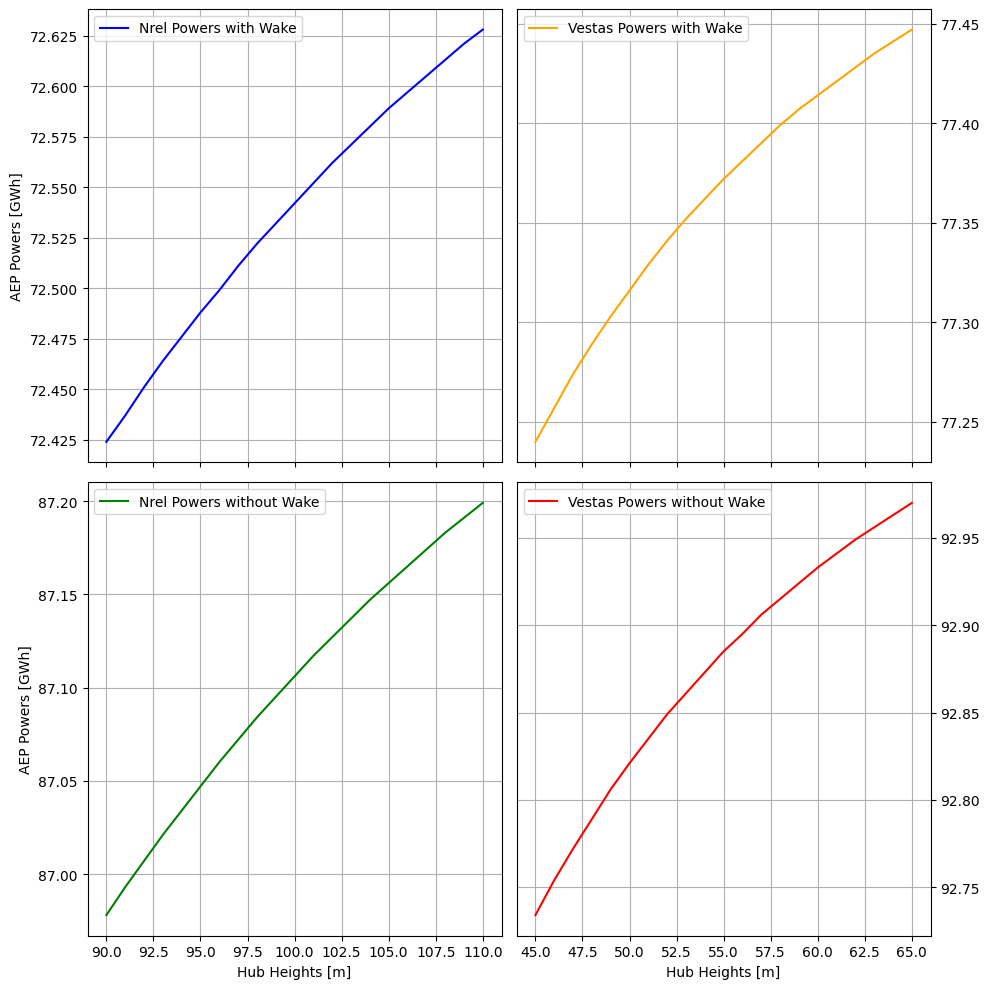

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Plot for n_wake
axs[0, 0].plot(n_x, n_wake, label='Nrel Powers with Wake', color='blue')
axs[0, 0].set_ylabel('AEP Powers [GWh]')
axs[0, 0].set_xticklabels([])  # Remove x-axis values
axs[0, 0].legend(loc='upper left')
axs[0, 0].grid(which='both')

# Plot for v_wake
axs[0, 1].plot(v_x, v_wake, label="Vestas Powers with Wake", color='orange')
# axs[0, 1].set_ylabel('AEP Powers [GWh]')
axs[0, 1].yaxis.tick_right()  # Move y-axis to the right
axs[0, 1].set_xticklabels([])  # Remove x-axis values
axs[0, 1].legend(loc='upper left')
axs[0, 1].grid(which='both')

# Plot for n_nowake
axs[1, 0].plot(n_x, n_nowake, label='Nrel Powers without Wake', color='green')
axs[1, 0].set_xlabel('Hub Heights [m]')
axs[1, 0].set_ylabel('AEP Powers [GWh]')
axs[1, 0].legend(loc='upper left')
axs[1, 0].grid(which='both')

# Plot for v_nowake
axs[1, 1].plot(v_x, v_nowake, label='Vestas Powers without Wake', color='red')
axs[1, 1].set_xlabel('Hub Heights [m]')
# axs[1, 1].set_ylabel('AEP Powers [GWh]')
axs[1, 1].yaxis.tick_right()  # Move y-axis to the right
axs[1, 1].legend(loc='upper left')
axs[1, 1].grid(which='both')

plt.tight_layout()  # Adjust the spacing between subplots
plt.show()

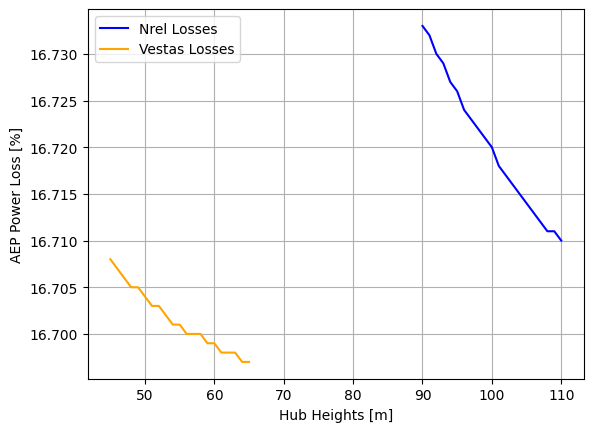

In [9]:
plt.plot(n_x, n_loss, label='Nrel Losses', color='blue')
plt.plot(v_x, v_loss, label='Vestas Losses', color='orange')
plt.xlabel('Hub Heights [m]')
plt.ylabel('AEP Power Loss [%]')
plt.legend(loc='upper left')
plt.grid(which='both')
plt.show()

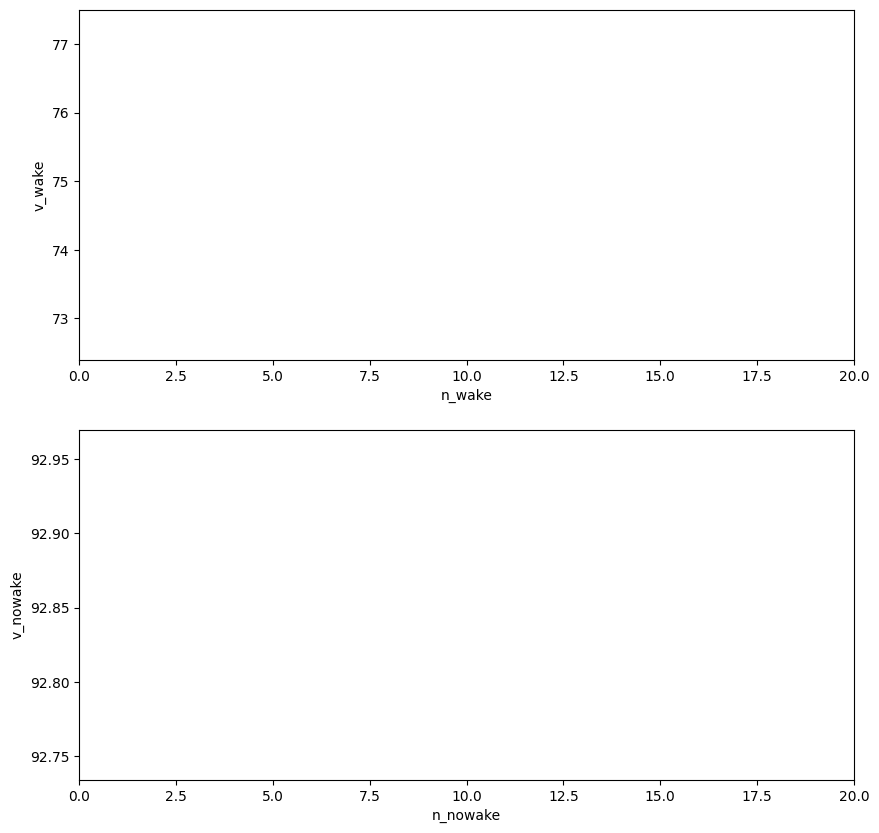

In [10]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# First subplot
axs[0].plot(n_wake, v_wake)
axs[0].set_xlim([0, 20])
axs[0].set_ylim([72.4, 77.5])
axs[0].set_xlabel('n_wake')
axs[0].set_ylabel('v_wake')

# Second subplot
axs[1].plot(n_nowake, v_nowake)
axs[1].set_xlim([0, 20])
axs[1].set_ylim([min(v_nowake), max(v_nowake)])
axs[1].set_xlabel('n_nowake')
axs[1].set_ylabel('v_nowake')

plt.show()